In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
import tqdm

In [2]:
from experiments import MLPDenoiser
from experiments import mmse_denoiser, grad_log_noisy_density, sample_from_mixture, prior_density, noisy_density
from experiments import algorithm1_sample, annealed_langevin
from experiments import algorithm2_sample
from experiments import p_sigma_1d, ddpm_marginal_1d, sample_circle
from experiments import reverse_paper_like, reverse_score_sde

### Experiment 1 - Visualizing Miyasawa's identity in 2D

We use a 2D Gaussian mixture as the prior p(x), for which:
- $p(y) = p(x) * g_σ$  is known analytically (still a Gaussian mixture)
- The MMSE denoiser x̂(y) = E[x|y] can be computed in closed form
- ∇_y log p(y) can be computed analytically

We verify that the denoiser residual f(y) = x̂(y) - y equals σ² ∇_y log p(y).
We also train a small MLP denoiser and show it learns this relationship.

In [3]:
# Mixture of 4 Gaussians in 2D
means = np.array([
    [2.0, 2.0],
    [-2.0, 2.0],
    [-2.0, -2.0],
    [2.0, -2.0],
])
covariances = [
    np.array([[0.3, 0.1], [0.1, 0.3]]),
    np.array([[0.3, -0.1], [-0.1, 0.3]]),
    np.array([[0.2, 0.0], [0.0, 0.5]]),
    np.array([[0.5, 0.0], [0.0, 0.2]]),
]
weights = np.array([0.25, 0.25, 0.25, 0.25])

For a Gaussian mixture, the MMSE denoiser can be computed as $\hat{x}(y) = \mathbb{E}[x|y] = \sum_{k=1}^K w_k(y) \mu_k(y)$ where :
- $w_k(y) \propto {w_k \mathcal{N}(y; \mu_k, \Sigma_k + \sigma^2 I)}$ are the posterior weights
- $\mu_k(y) = \Sigma_k (\Sigma_k + \sigma^2 I)^{-1} y + \sigma^2 (\Sigma_k + \sigma^2 I)^{-1} \mu_k$ are the posterior means

The gradient of the log density can be computed as $\nabla_y \log p(y) = \sum_{k=1}^K w_k(y) \Sigma_k^{-1} (\mu_k - y)$.

In [5]:
sigma = 0.5  # noise level
grid_range = np.linspace(-5, 5, 30)
Y1, Y2 = np.meshgrid(grid_range, grid_range)
grid_points = np.stack([Y1.ravel(), Y2.ravel()], axis=1)

# Analytical computation on grid
residuals = []
score_times_sigma2 = []
for y in grid_points:
    xhat = mmse_denoiser(y, sigma, weights, means, covariances)
    f_y = xhat - y
    residuals.append(f_y)
    
    score = grad_log_noisy_density(y, sigma, weights, means, covariances)
    score_times_sigma2.append(sigma**2 * score)

residuals = np.array(residuals)
score_times_sigma2 = np.array(score_times_sigma2)

Number of parameters in MLP denoiser: 8642
Training MLP denoiser...
  Epoch   50, MSE loss: 0.245165, LR: 0.000500
  Epoch  100, MSE loss: 0.187375, LR: 0.000000
  Epoch  150, MSE loss: 0.188876, LR: 0.000500
  Epoch  200, MSE loss: 0.167120, LR: 0.001000
  Epoch  250, MSE loss: 0.157802, LR: 0.000500
  Epoch  300, MSE loss: 0.154084, LR: 0.000000
  Epoch  350, MSE loss: 0.153088, LR: 0.000500
  Epoch  400, MSE loss: 0.151111, LR: 0.001000
  Epoch  450, MSE loss: 0.147948, LR: 0.000500
  Epoch  500, MSE loss: 0.147868, LR: 0.000000


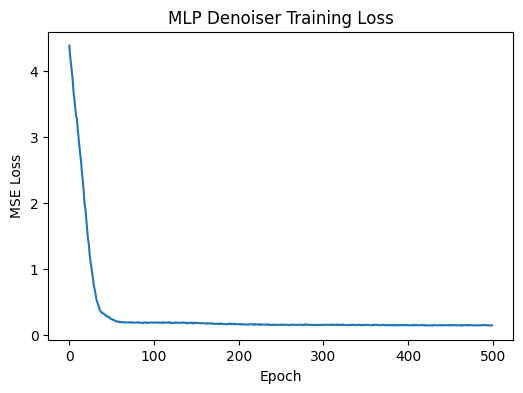

In [7]:
# Training the MLP denoiser
model = MLPDenoiser(hidden=64)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

print(f"Number of parameters in MLP denoiser: {sum(p.numel() for p in model.parameters())}")

losst = []
epochs = 500
batch_size = 4096

print("Training MLP denoiser...")
for epoch in range(epochs):
    x_train = sample_from_mixture(batch_size, means, covariances, weights)
    noise = sigma * np.random.randn(batch_size, 2)
    y_train = x_train + noise
    
    y_t = torch.tensor(y_train, dtype=torch.float32)
    x_t = torch.tensor(x_train, dtype=torch.float32)
    
    xhat = model(y_t)
    loss = ((xhat - x_t)**2).mean()
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()

    losst.append(loss.item())
    
    if (epoch + 1) % 50 == 0:
        current_lr = scheduler.get_last_lr()[0]
        print(f"  Epoch {epoch+1:4d}, MSE loss: {loss.item():.6f}, LR: {current_lr:.6f}")

# visualize the loss curve
plt.figure(figsize=(6, 4))
plt.plot(losst)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("MLP Denoiser Training Loss")
plt.show()

In [8]:
# Compute MLP residuals on the grid
model.eval()
with torch.no_grad():
    y_grid_t = torch.tensor(grid_points, dtype=torch.float32)
    xhat_mlp = model(y_grid_t).numpy()
    residuals_mlp = xhat_mlp - grid_points

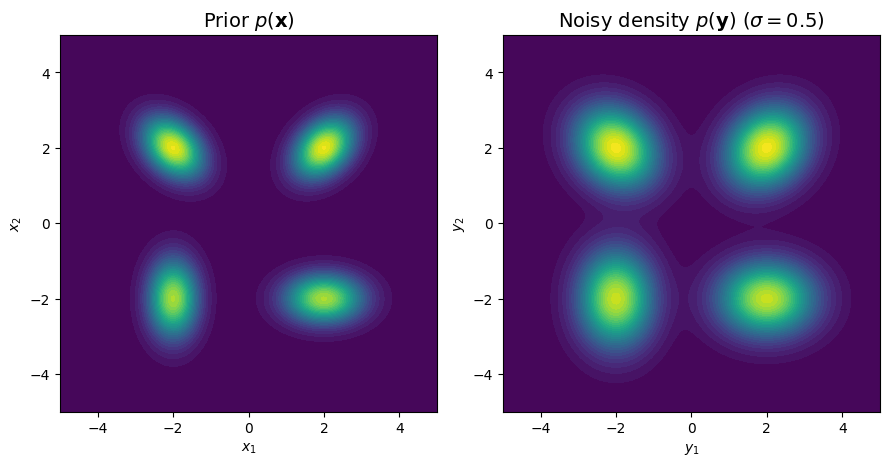

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(9, 8))

fine_grid = np.linspace(-5, 5, 200)
FY1, FY2 = np.meshgrid(fine_grid, fine_grid)
fine_points = np.stack([FY1.ravel(), FY2.ravel()], axis=1)

px = np.array([prior_density(pt, weights, means, covariances) for pt in fine_points]).reshape(200, 200)
py = np.array([noisy_density(pt, sigma, weights, means, covariances) for pt in fine_points]).reshape(200, 200)

axes[0].contourf(FY1, FY2, px, levels=30, cmap='viridis')
axes[0].set_title(r'Prior $p(\mathbf{x})$', fontsize=14)
axes[0].set_xlabel('$x_1$'); axes[0].set_ylabel('$x_2$')
axes[0].set_aspect('equal')

axes[1].contourf(FY1, FY2, py, levels=30, cmap='viridis')
axes[1].set_title(r'Noisy density $p(\mathbf{y})$ ($\sigma=$'+f'{sigma})', fontsize=14)
axes[1].set_xlabel('$y_1$'); axes[1].set_ylabel('$y_2$')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.savefig('exp1a.png', dpi=150, bbox_inches='tight')
plt.show()

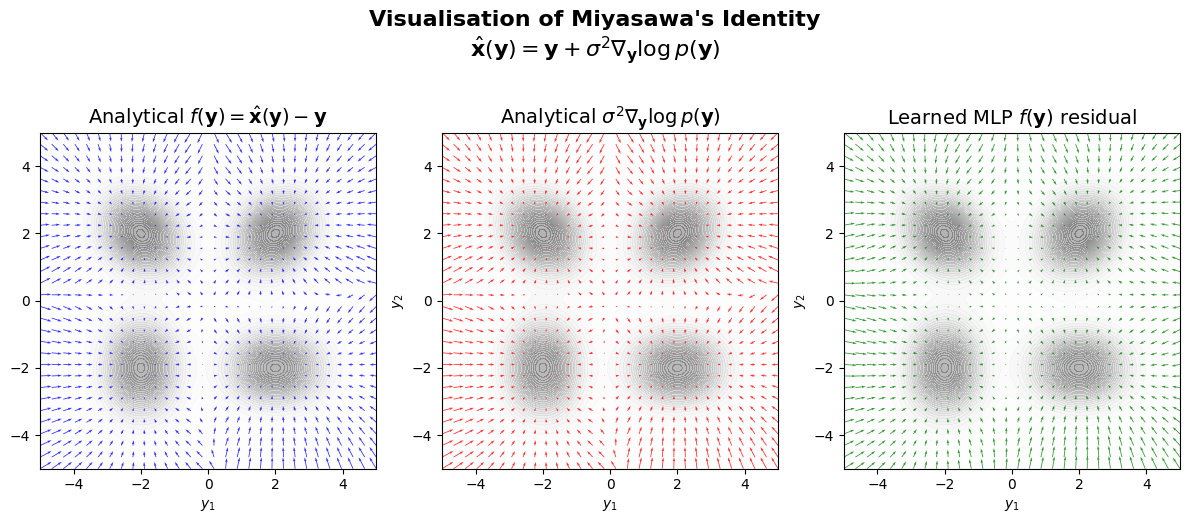

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

fine_grid = np.linspace(-5, 5, 200)
FY1, FY2 = np.meshgrid(fine_grid, fine_grid)
fine_points = np.stack([FY1.ravel(), FY2.ravel()], axis=1)

px = np.array([prior_density(pt, weights, means, covariances) for pt in fine_points]).reshape(200, 200)
py = np.array([noisy_density(pt, sigma, weights, means, covariances) for pt in fine_points]).reshape(200, 200)

axes[0].contourf(FY1, FY2, py, levels=30, cmap='gray_r', alpha=0.3)
axes[0].quiver(Y1, Y2, residuals[:, 0].reshape(30, 30), 
                  residuals[:, 1].reshape(30, 30), color='blue', alpha=0.8)
axes[0].set_title(r'Analytical $f(\mathbf{y}) = \hat{\mathbf{x}}(\mathbf{y}) - \mathbf{y}$', fontsize=14)
axes[0].set_xlabel('$y_1$'); axes[2].set_ylabel('$y_2$')
axes[0].set_aspect('equal')

axes[1].contourf(FY1, FY2, py, levels=30, cmap='gray_r', alpha=0.3)
axes[1].quiver(Y1, Y2, score_times_sigma2[:, 0].reshape(30, 30),
                  score_times_sigma2[:, 1].reshape(30, 30), color='red', alpha=0.8)
axes[1].set_title(r'Analytical $\sigma^2 \nabla_{\mathbf{y}} \log p(\mathbf{y})$', fontsize=14)
axes[1].set_xlabel('$y_1$'); axes[1].set_ylabel('$y_2$')
axes[1].set_aspect('equal')

axes[2].contourf(FY1, FY2, py, levels=30, cmap='gray_r', alpha=0.3)
axes[2].quiver(Y1, Y2, residuals_mlp[:, 0].reshape(30, 30), residuals_mlp[:, 1].reshape(30, 30), color='green', alpha=0.8)
axes[2].set_title(r'Learned MLP $f(\mathbf{y})$ residual', fontsize=14)
axes[2].set_xlabel('$y_1$'); axes[2].set_ylabel('$y_2$')
axes[2].set_aspect('equal')

plt.suptitle("Visualisation of Miyasawa's Identity\n" r"$\hat{\mathbf{x}}(\mathbf{y}) = \mathbf{y} + \sigma^2 \nabla_{\mathbf{y}} \log p(\mathbf{y})$", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('exp1b.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# Generate a large test set that follows the true distribution p(y)
x_test = sample_from_mixture(10000, means, covariances, weights)
noise_test = sigma * np.random.randn(10000, 2)
y_test = x_test + noise_test

# Compute analytical denoiser residual on these points
xhat_test_analytical = np.array([mmse_denoiser(y, sigma, weights, means, covariances) for y in y_test])
residuals_test_analytical = xhat_test_analytical - y_test

# Compute analytical score on these points
score_times_sigma2_test = np.array([sigma**2 * grad_log_noisy_density(y, sigma, weights, means, covariances) for y in y_test])

# Compute MLP prediction on these points
model.eval()
with torch.no_grad():
    y_test_t = torch.tensor(y_test, dtype=torch.float32)
    xhat_mlp_test = model(y_test_t).numpy()
    residuals_mlp_test = xhat_mlp_test - y_test

# Calculate Errors
error_analytical = np.linalg.norm(residuals_test_analytical - score_times_sigma2_test, axis=1)
error_mlp = np.linalg.norm(residuals_mlp_test - score_times_sigma2_test, axis=1)

print(f"Analytical denoiser vs score : RMSE error = {np.sqrt(error_analytical.mean()):.2e}")
print(f"MLP denoiser vs score : RMSE error = {np.sqrt(error_mlp.mean()):.2e}")

Analytical denoiser vs score : RMSE error = 1.83e-08
MLP denoiser vs score : RMSE error = 2.30e-01


### Experiment 2: Coarse-to-fine stochastic ascent (Algorithm 1) in 2D

We implement Algorithm 1 from the paper and compare with annealed Langevin dynamics (Song & Ermon, NeurIPS 2019).

In [25]:
means = np.array([[2, 2], [-2, 2], [-2, -2], [2, -2], [0, 0]])
covariances = [0.15*np.eye(2) for _ in range(5)]
weights = np.array([0.2, 0.2, 0.2, 0.2, 0.2])

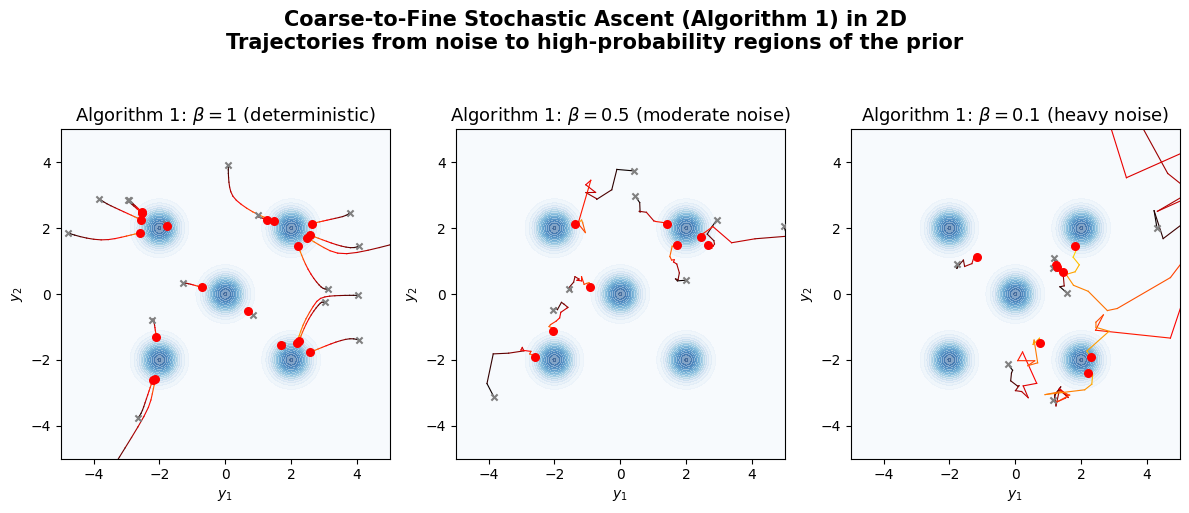

In [28]:
np.random.seed(0)
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

ax = axes[0]
fine = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(fine, fine)
Z = np.array([noisy_density(np.array([x, y]), 0.01, weights, means, covariances) for x, y in
              zip(X.ravel(), Y.ravel())]).reshape(200, 200)
ax.contourf(X, Y, Z, levels=20, cmap='Blues', alpha=0.5)

for _ in range(20):
    traj, sigmas, _ = algorithm1_sample(sigma_0=3.0, beta=1.0, h0=0.02, means=means, covariances=covariances, weights=weights)
    colors = plt.cm.hot(np.linspace(0, 0.8, len(traj)))
    for i in range(len(traj)-1):
        ax.plot([traj[i, 0], traj[i+1, 0]], [traj[i, 1], traj[i+1, 1]], 
                color=colors[i], linewidth=0.8)
    ax.scatter(traj[0, 0], traj[0, 1], c='gray', s=20, zorder=5, marker='x')
    ax.scatter(traj[-1, 0], traj[-1, 1], c='red', s=30, zorder=5, marker='o')
ax.set_title(r'Algorithm 1: $\beta=1$ (deterministic)', fontsize=13)
ax.set_xlabel('$y_1$'); ax.set_ylabel('$y_2$')
ax.set_aspect('equal'); ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)

ax = axes[1]
ax.contourf(X, Y, Z, levels=20, cmap='Blues', alpha=0.5)
for _ in range(8):
    traj, sigmas, _ = algorithm1_sample(sigma_0=3.0, beta=0.5, h0=0.02, means=means, covariances=covariances, weights=weights)
    colors = plt.cm.hot(np.linspace(0, 0.8, len(traj)))
    for i in range(len(traj)-1):
        ax.plot([traj[i, 0], traj[i+1, 0]], [traj[i, 1], traj[i+1, 1]], 
                color=colors[i], linewidth=0.8)
    ax.scatter(traj[0, 0], traj[0, 1], c='gray', s=20, zorder=5, marker='x')
    ax.scatter(traj[-1, 0], traj[-1, 1], c='red', s=30, zorder=5, marker='o')
ax.set_title(r'Algorithm 1: $\beta=0.5$ (moderate noise)', fontsize=13)
ax.set_xlabel('$y_1$'); ax.set_ylabel('$y_2$')
ax.set_aspect('equal'); ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)

ax = axes[2]
ax.contourf(X, Y, Z, levels=20, cmap='Blues', alpha=0.5)
for _ in range(8):
    traj, sigmas, _ = algorithm1_sample(sigma_0=3.0, beta=0.1, h0=0.02, means=means, covariances=covariances, weights=weights)
    colors = plt.cm.hot(np.linspace(0, 0.8, len(traj)))
    for i in range(len(traj)-1):
        ax.plot([traj[i, 0], traj[i+1, 0]], [traj[i, 1], traj[i+1, 1]], 
                color=colors[i], linewidth=0.8)
    ax.scatter(traj[0, 0], traj[0, 1], c='gray', s=20, zorder=5, marker='x')
    ax.scatter(traj[-1, 0], traj[-1, 1], c='red', s=30, zorder=5, marker='o')
ax.set_title(r'Algorithm 1: $\beta=0.1$ (heavy noise)', fontsize=13)
ax.set_xlabel('$y_1$'); ax.set_ylabel('$y_2$')
ax.set_aspect('equal'); ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)

plt.suptitle("Coarse-to-Fine Stochastic Ascent (Algorithm 1) in 2D\n" "Trajectories from noise to high-probability regions of the prior", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('exp2a.png', dpi=150, bbox_inches='tight')
plt.show()

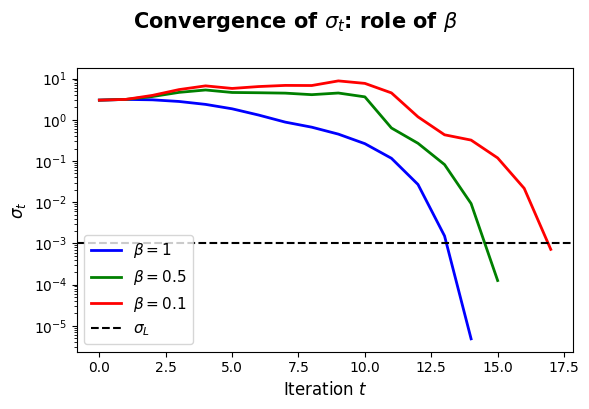

In [31]:
np.random.seed(0)
fig, ax = plt.subplots(figsize=(6,4))

for beta_val, color, label in [(1.0, 'blue', r'$\beta=1$'), (0.5, 'green', r'$\beta=0.5$'), (0.1, 'red', r'$\beta=0.1$')]:
    np.random.seed(0)
    _, sigmas, _ = algorithm1_sample(sigma_0=3.0, beta=beta_val, h0=0.05, means=means, covariances=covariances, weights=weights)
    ax.semilogy(sigmas, color=color, label=label, linewidth=2)
ax.axhline(y=0.001, color='black', linestyle='--', label=r'$\sigma_L$')
ax.set_xlabel('Iteration $t$', fontsize=12)
ax.set_ylabel(r'$\sigma_t$', fontsize=12)
ax.legend(fontsize=11)

plt.suptitle(r"Convergence of $\sigma_t$: role of $\beta$", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('exp2b.png', dpi=150, bbox_inches='tight')
plt.show()

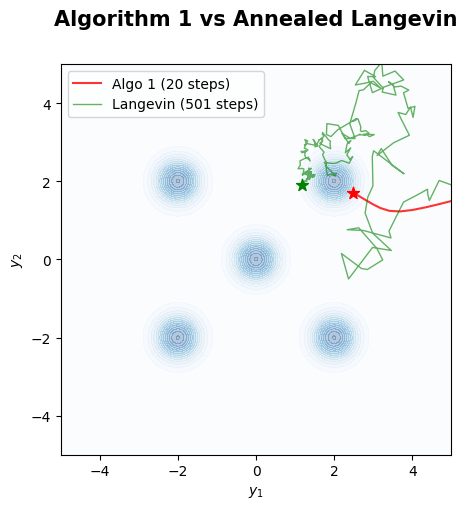

In [35]:
np.random.seed(0)
fig, ax = plt.subplots(figsize=(9,5))
ax.contourf(X, Y, Z, levels=20, cmap='Blues', alpha=0.3)

np.random.seed(0)
traj1, _, _ = algorithm1_sample(sigma_0=3.0, beta=1.0, h0=0.02, means=means, covariances=covariances, weights=weights)
ax.plot(traj1[:, 0], traj1[:, 1], 'r-', linewidth=1.5, alpha=0.8, label=f'Algo 1 ({len(traj1)} steps)')
ax.scatter(traj1[-1, 0], traj1[-1, 1], c='red', s=80, zorder=5, marker='*')

np.random.seed(0)
sigmas_langevin = np.geomspace(3.0, 0.01, 10)
traj2, _ = annealed_langevin(sigmas_langevin, epsilon=1e-6, T_per_level=50, means=means, covariances=covariances, weights=weights)
ax.plot(traj2[:, 0], traj2[:, 1], 'g-', linewidth=1.0, alpha=0.6, label=f'Langevin ({len(traj2)} steps)')
ax.scatter(traj2[-1, 0], traj2[-1, 1], c='green', s=80, zorder=5, marker='*')

ax.set_xlabel('$y_1$'); ax.set_ylabel('$y_2$')
ax.set_aspect('equal'); ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)
ax.legend(fontsize=10)

plt.suptitle("Algorithm 1 vs Annealed Langevin", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('exp2c.png', dpi=150, bbox_inches='tight')
plt.show()

### Experiment 3 : Linear Inverse Problem — Constrained Sampling (Algorithm 2) in 2D

We observe only one coordinate of a 2D point: $x^c = M^T x = x_1$ and the algorithm must reconstruct $x_2$ using the prior.

In [36]:
means = np.array([[2, 2], [-2, 2], [-2, -2], [2, -2]])
covariances = [0.3 * np.eye(2) for _ in range(4)]
weights = np.array([0.25, 0.25, 0.25, 0.25])
M = np.array([[1], [0]])

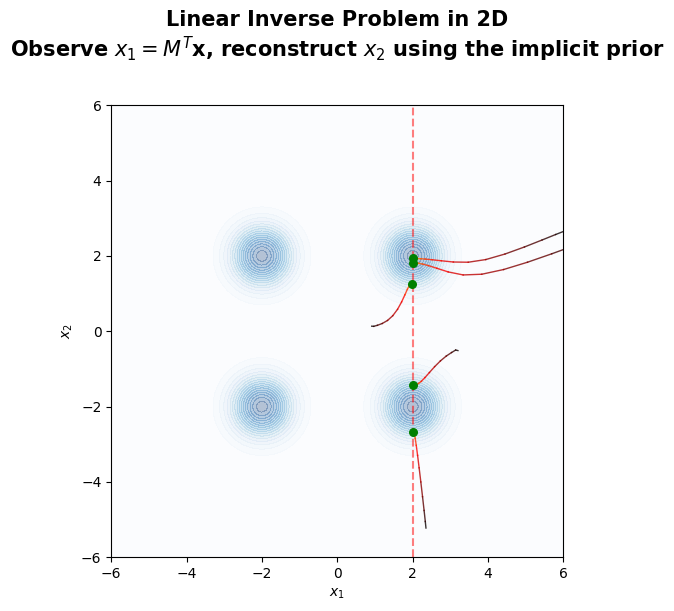

In [40]:
np.random.seed(10)
x_true = np.array([2.0, 2.0]) # true point from top-right cluster
x_c = x_true[0] # observe x_1 = 2.0

fig, ax = plt.subplots(figsize=(9, 6))

fine = np.linspace(-6, 6, 200)
Xg, Yg = np.meshgrid(fine, fine)
Z = np.array([prior_density(np.array([x, y]), weights, means, covariances) for x, y in zip(Xg.ravel(), Yg.ravel())]).reshape(200, 200)

ax.contourf(Xg, Yg, Z, levels=20, cmap='Blues', alpha=0.3)
ax.axvline(x=x_c, color='red', linewidth=1.5, linestyle='--', alpha=0.5)
final_x2 = []
for i in range(5):
    traj, _, _, _ = algorithm2_sample(x_c, sigma_0=3.0, beta=1.0, h0=0.05, weights=weights, means=means, covariances=covariances, M=M)
    colors_t = plt.cm.hot(np.linspace(0, 0.8, len(traj)))
    for j in range(len(traj)-1):
        ax.plot([traj[j,0], traj[j+1,0]], [traj[j,1], traj[j+1,1]], 
                color=colors_t[j], linewidth=1.0, alpha=0.8)
    ax.scatter(traj[-1, 0], traj[-1, 1], c='green', s=30, zorder=5)
    final_x2.append(traj[-1, 1])
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_aspect('equal'); ax.set_xlim(-6, 6); ax.set_ylim(-6, 6)

plt.suptitle("Linear Inverse Problem in 2D\n" r"Observe $x_1 = M^T \mathbf{x}$, reconstruct $x_2$ using the implicit prior", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('exp3a.png', dpi=150, bbox_inches='tight')
plt.show()

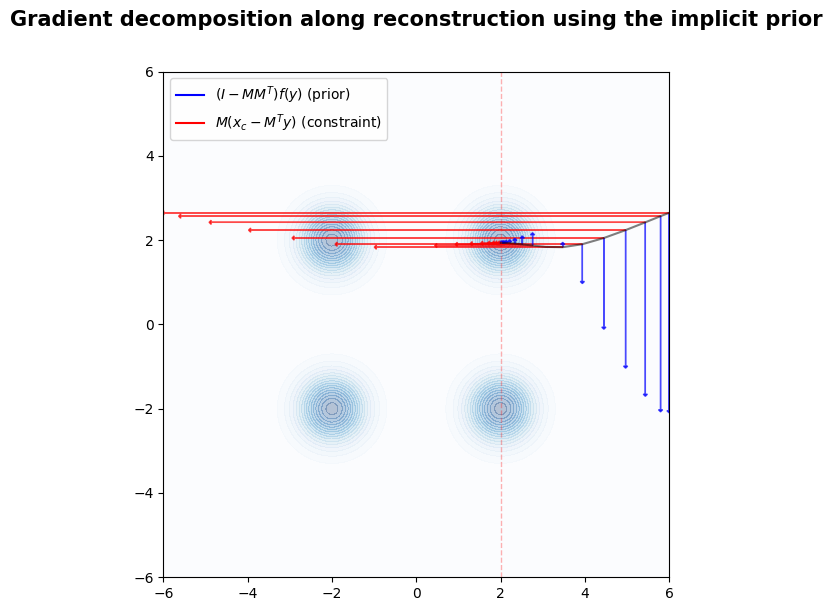

In [41]:
np.random.seed(10)
x_true = np.array([2.0, 2.0]) # true point from top-right cluster
x_c = x_true[0] # observe x_1 = 2.0

fig, ax = plt.subplots(figsize=(9, 6))

fine = np.linspace(-6, 6, 200)
Xg, Yg = np.meshgrid(fine, fine)
Z = np.array([prior_density(np.array([x, y]), weights, means, covariances) for x, y in zip(Xg.ravel(), Yg.ravel())]).reshape(200, 200)

np.random.seed(10)
traj, sigmas, gp, gc = algorithm2_sample(x_c, sigma_0=3.0, beta=1.0, h0=0.05, weights=weights, means=means, covariances=covariances, M=M)
n_arrows = min(15, len(gp))
indices = np.linspace(0, len(gp)-1, n_arrows, dtype=int)
ax.contourf(Xg, Yg, Z, levels=20, cmap='Blues', alpha=0.3)
ax.plot(traj[:, 0], traj[:, 1], 'k-', linewidth=1.5, alpha=0.5)
scale = 3.0
for idx in indices:
    y_pt = traj[idx]
    ax.arrow(y_pt[0], y_pt[1], gp[idx, 0]*scale, gp[idx, 1]*scale, head_width=0.1, head_length=0.05, fc='blue', ec='blue', alpha=0.7)
    ax.arrow(y_pt[0], y_pt[1], gc[idx, 0]*scale, gc[idx, 1]*scale, head_width=0.1, head_length=0.05, fc='red', ec='red', alpha=0.7)
ax.axvline(x=x_c, color='red', linewidth=1, linestyle='--', alpha=0.3)
ax.plot([], [], color='blue', label=r'$(I-MM^T)f(y)$ (prior)')
ax.plot([], [], color='red', label=r'$M(x_c - M^Ty)$ (constraint)')
ax.legend(fontsize=10); ax.set_aspect('equal')
ax.set_xlim(-6, 6); ax.set_ylim(-6, 6)

plt.suptitle("Gradient decomposition along reconstruction using the implicit prior", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('exp3b.png', dpi=150, bbox_inches='tight')
plt.show()

### Experiment 4: Gaussian Scale-Space & Forward Diffusion Process

In [43]:
# Prior: mixture of 3 Gaussians in 1D
mus_1d = [-3, 0, 3]
sigmas_1d = [0.3, 0.5, 0.3]
weights_1d = [0.3, 0.4, 0.3]

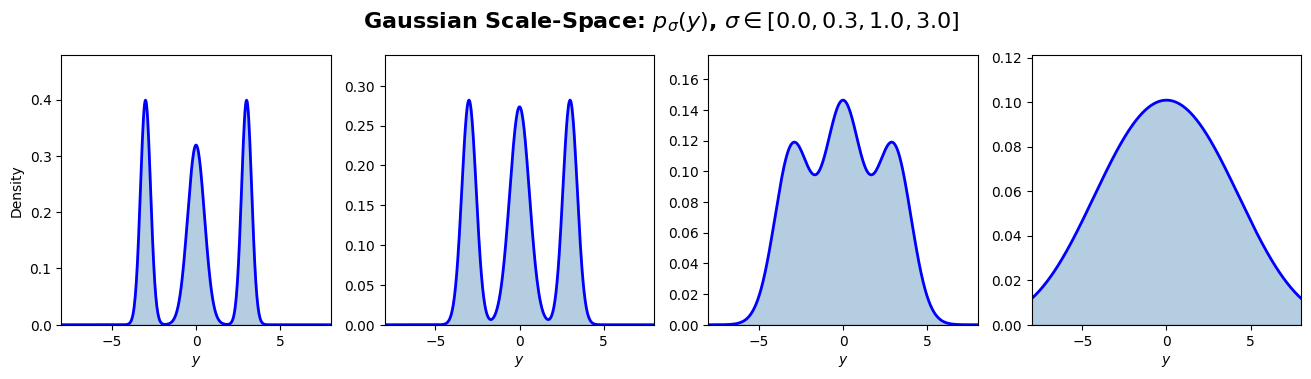

In [54]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))

x_range = np.linspace(-8, 8, 500)
sigma_values = [0.00, 0.3, 1.0, 3.0]

for i, sigma in enumerate(sigma_values):
    ax = axes[i]
    density = np.array([p_sigma_1d(x, sigma, weights_1d=weights_1d, mus_1d=mus_1d, sigmas_1d=sigmas_1d) for x in x_range])
    ax.fill_between(x_range, density, alpha=0.4, color='steelblue')
    ax.plot(x_range, density, 'b-', linewidth=2)
    ax.set_xlabel('$y$')
    if i == 0:
        ax.set_ylabel('Density')
    ax.set_ylim(0, max(density) * 1.2)
    ax.set_xlim(-8, 8)

fig.suptitle(f"Gaussian Scale-Space: $p_\\sigma(y)$, $\\sigma \\in {sigma_values}$", fontsize=16, fontweight='bold', y=1.01)
plt.savefig('exp4a.png', dpi=150, bbox_inches='tight')
plt.show()

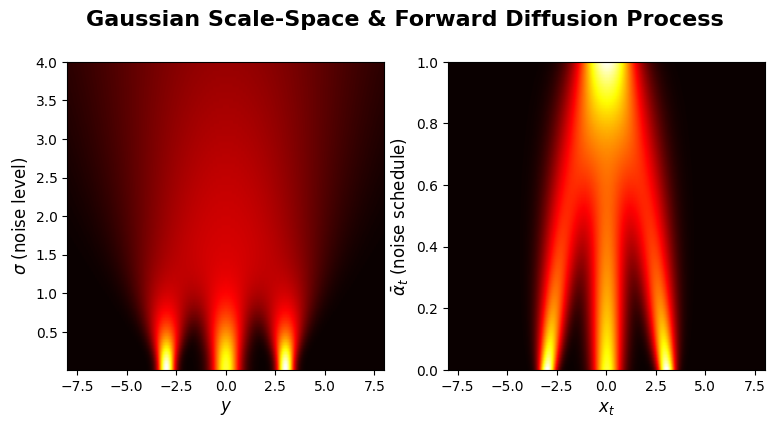

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

ax_ss = axes[0]
sigma_range = np.linspace(0.01, 4.0, 100)
SS = np.zeros((len(sigma_range), len(x_range)))
for i, sigma in enumerate(sigma_range):
    SS[i] = np.array([p_sigma_1d(x, sigma, weights_1d=weights_1d, mus_1d=mus_1d, sigmas_1d=sigmas_1d) for x in x_range])
ax_ss.imshow(SS, aspect='auto', origin='lower', cmap='hot', extent=[x_range[0], x_range[-1], sigma_range[0], sigma_range[-1]])
ax_ss.set_xlabel('$y$', fontsize=12)
ax_ss.set_ylabel(r'$\sigma$ (noise level)', fontsize=12)

ax_ddpm = axes[1]
alpha_bar_range = np.linspace(0.999, 0.01, 100)
DDPM = np.zeros((len(alpha_bar_range), len(x_range)))
for i, ab in enumerate(alpha_bar_range):
    DDPM[i] = np.array([ddpm_marginal_1d(x, ab, weights_1d=weights_1d, mus_1d=mus_1d, sigmas_1d=sigmas_1d) for x in x_range])
ax_ddpm.imshow(DDPM, aspect='auto', origin='lower', cmap='hot', extent=[x_range[0], x_range[-1], 0, 1])
ax_ddpm.set_xlabel('$x_t$', fontsize=12)
ax_ddpm.set_ylabel(r'$\bar{\alpha}_t$ (noise schedule)', fontsize=12)

fig.suptitle("Gaussian Scale-Space & Forward Diffusion Process\n", fontsize=16, fontweight='bold', y=1.01)
plt.savefig('exp4b.png', dpi=150, bbox_inches='tight')
plt.show()

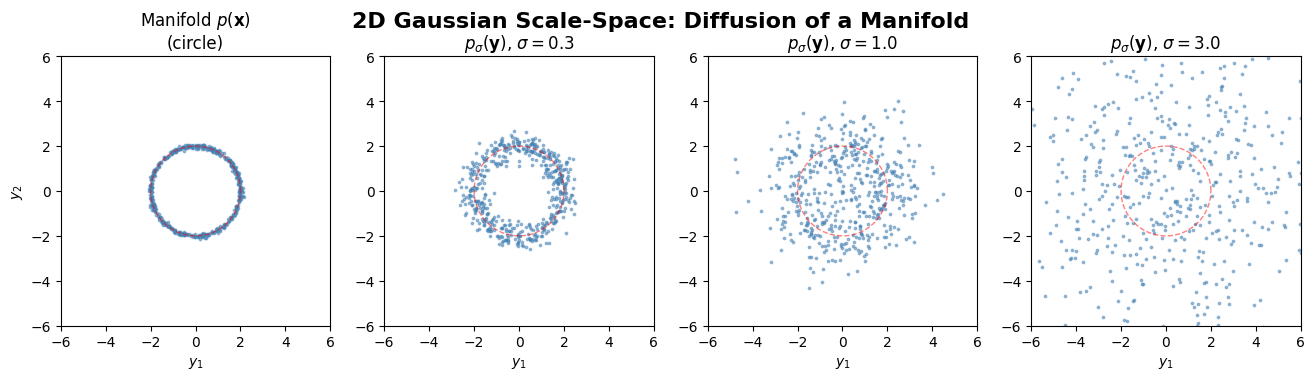

In [58]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))

circle_data = sample_circle(500, radius=2.0, noise_std=0.05)
noise_levels_2d = [0.0, 0.3, 1.0, 3.0]

for i, sigma in enumerate(noise_levels_2d):
    ax = axes[i]
    noisy_data = circle_data + sigma * np.random.randn(*circle_data.shape)
    
    ax.scatter(noisy_data[:, 0], noisy_data[:, 1], s=3, alpha=0.5, c='steelblue')
    theta = np.linspace(0, 2*np.pi, 100)
    ax.plot(2*np.cos(theta), 2*np.sin(theta), 'r--', linewidth=1, alpha=0.5)
    
    ax.set_xlim(-6, 6); ax.set_ylim(-6, 6)
    ax.set_aspect('equal')
    if sigma == 0.0:
        ax.set_title('Manifold $p(\\mathbf{x})$\n(circle)', fontsize=12)
    else:
        ax.set_title(f'$p_\\sigma(\\mathbf{{y}})$, $\\sigma = {sigma}$', fontsize=12)
    ax.set_xlabel('$y_1$'); 
    if i == 0: ax.set_ylabel('$y_2$')

fig.suptitle("2D Gaussian Scale-Space: Diffusion of a Manifold\n", fontsize=16, fontweight='bold', y=1.01)
plt.savefig('exp4c.png', dpi=150, bbox_inches='tight')
plt.show()

### Experiment 5

In [60]:
means = np.array([[2, 2], [-2, 2], [-2, -2], [2, -2], [0, 0]])
covs = [
    np.array([[0.2, 0.05],[0.05, 0.25]]),
    np.array([[0.25,-0.05],[-0.05,0.2]]),
    0.18*np.eye(2),
    0.22*np.eye(2),
    0.35*np.eye(2),
]
weights = np.ones(len(means))/len(means)

In [65]:
snapshots = reverse_paper_like(n_particles=100, sigma_0=3.0, sigma_L=0.01, h0=0.05, beta=1.0, seed=1, means=means, covs=covs, weights=weights)

Plotting snapshots: 100%|██████████| 4/4 [01:26<00:00, 21.66s/it]


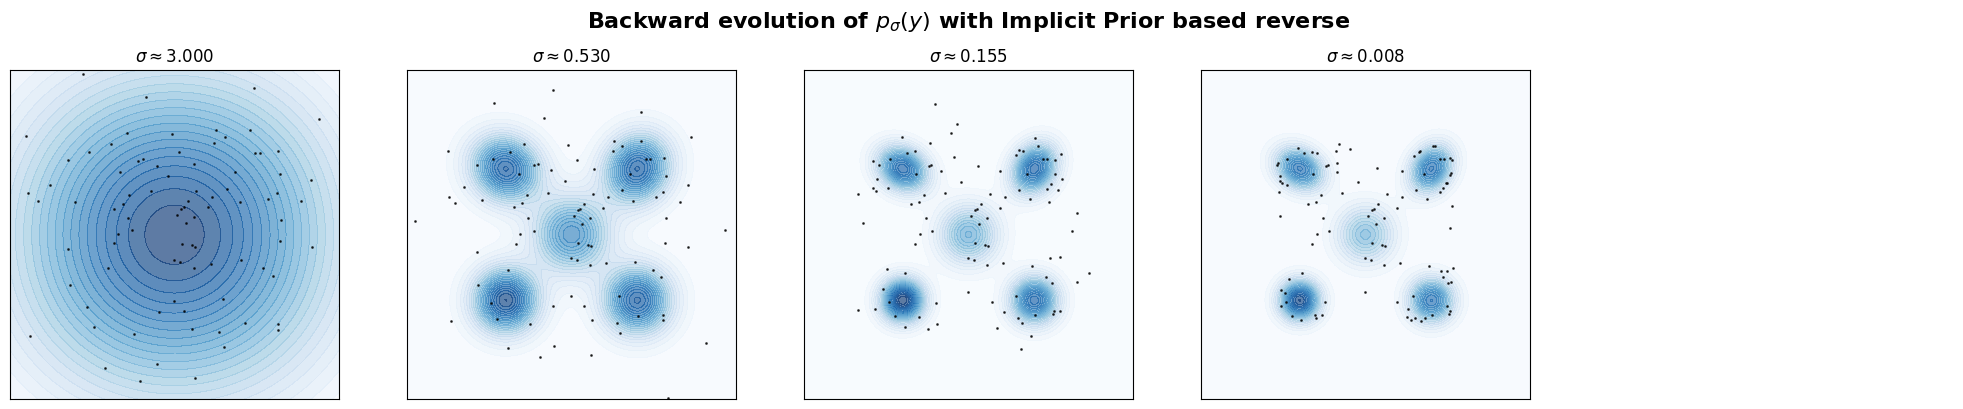

In [69]:
n = len(snapshots)
cols = 5
rows = 1
grid_lim = 5.0
fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
axes = np.array(axes).reshape(-1)

# density grid for contours
fine = np.linspace(-grid_lim, grid_lim, 200)
X, Y = np.meshgrid(fine, fine)
pts = np.stack([X.ravel(), Y.ravel()], axis=1)

count = 0
for i, (sigma, y) in tqdm.tqdm(enumerate(snapshots), desc="Plotting snapshots", total=len(snapshots)):
    if i in [0, 1, 2, 3]:
        ax = axes[count]
        count += 1
        Z = np.array([noisy_density(p, sigma, weights, means, covs) for p in pts]).reshape(200, 200)
        ax.contourf(X, Y, Z, levels=25, cmap='Blues', alpha=0.65)
        ax.scatter(y[:,0], y[:,1], s=1, c='black', alpha=0.7)
        ax.set_title(rf"$\sigma \approx {sigma:.3f}$", fontsize=12)
        ax.set_xlim(-grid_lim, grid_lim); ax.set_ylim(-grid_lim, grid_lim)
        ax.set_aspect('equal')
        ax.set_xticks([]); ax.set_yticks([])

for j in range(i+1, len(axes)):
    axes[j].axis('off')

fig.suptitle("Backward evolution of $p_\\sigma(y)$ with Implicit Prior based reverse", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("exp5a.png", dpi=150, bbox_inches='tight')
plt.show()


In [63]:
snapshots = reverse_score_sde(n_particles=100, sigma_0=3.0, sigma_L=0.01, n_levels=12, n_inner=50, seed=1, means=means, covs=covs, weights=weights)

Score-based reverse SDE: 100%|██████████| 11/11 [00:34<00:00,  3.17s/it]


Plotting snapshots: 100%|██████████| 12/12 [01:55<00:00,  9.60s/it]


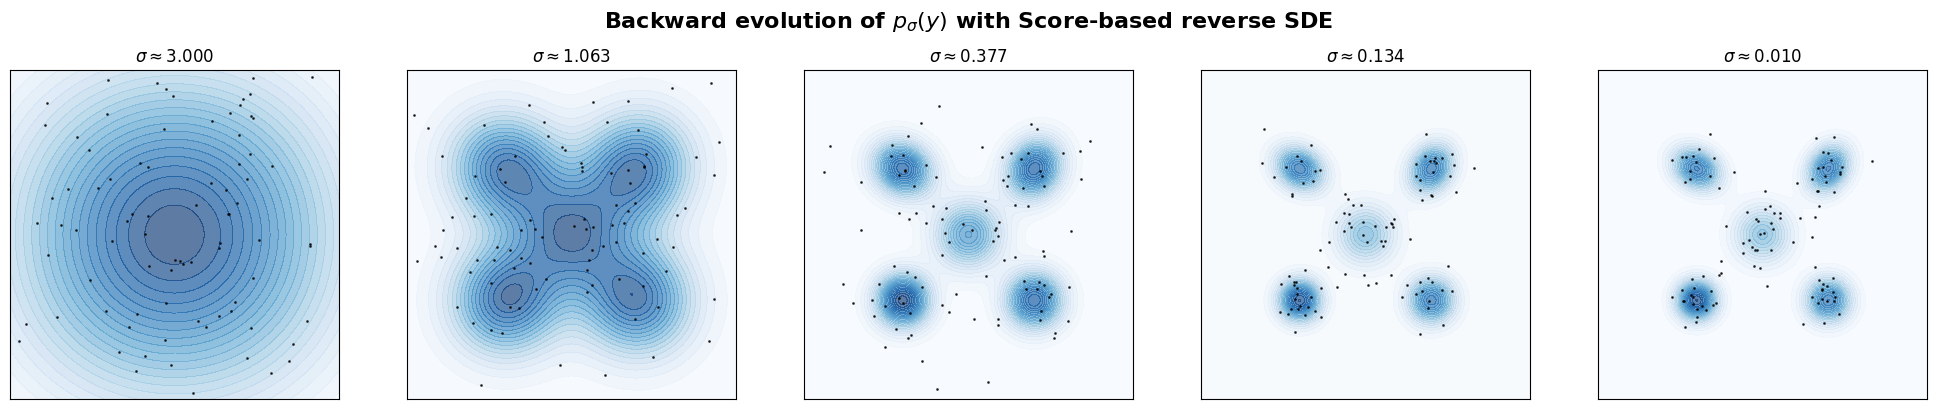

In [64]:
n = len(snapshots)
cols = 5
rows = 1
grid_lim = 5.0
fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
axes = np.array(axes).reshape(-1)

# density grid for contours
fine = np.linspace(-grid_lim, grid_lim, 200)
X, Y = np.meshgrid(fine, fine)
pts = np.stack([X.ravel(), Y.ravel()], axis=1)

count = 0
for i, (sigma, y) in tqdm.tqdm(enumerate(snapshots), desc="Plotting snapshots", total=len(snapshots)):
    if i in [0, 2, 4, 6, 11]:
        ax = axes[count]
        count += 1
        Z = np.array([noisy_density(p, sigma, weights, means, covs) for p in pts]).reshape(200, 200)
        ax.contourf(X, Y, Z, levels=25, cmap='Blues', alpha=0.65)
        ax.scatter(y[:,0], y[:,1], s=1, c='black', alpha=0.7)
        ax.set_title(rf"$\sigma \approx {sigma:.3f}$", fontsize=12)
        ax.set_xlim(-grid_lim, grid_lim); ax.set_ylim(-grid_lim, grid_lim)
        ax.set_aspect('equal')
        ax.set_xticks([]); ax.set_yticks([])

for j in range(i+1, len(axes)):
    axes[j].axis('off')

fig.suptitle("Backward evolution of $p_\\sigma(y)$ with Score-based reverse SDE", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("exp5b.png", dpi=150, bbox_inches='tight')
plt.show()
